# Aim:

This notebook will be used to develop and then use a data loading pipeline (using DataStack.py) to take raw DEM data and export tiles of only hillshade, for both training and model deployment. Training will be done using a simple segmentation UNET (in Colab) and model deployment will be done natively in VSCode. 

The aim of this is to do initial exploration for possible field target areas based on density of small subcircular depression features in areas of interest, which are not captured well by raw DEM 'imagery'. Areas of interest have been predefined by desk geology studies using BGS maps at different scales and by exploring the literature for ancient Variscan Structure. The main area the model will be deployed in is Bridgwater/Taunton, and Lizard. 

The model will be trained on a small subset, and deployed on the whole region. This model is not meant to generalise to different geographies, so leakage into 'test' set is not a concern for me, as this is a coarse appraisal process. 

Steps Taken:

1. QGIS to build label polygons for training area (A region around the Quantock Hills)
2. Export training tiles to google drive, for colab.
3. Build and train model, overfitting is not too much of a concern in this case.
4. Export deployment tiles (of AOIs) locally
5. Build inference loop to deploy model and calculate densities of SCDs in 2D voxels. Test/confirm on areas where we dont expect much. 

In [1]:
import rasterio as rio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.crs import CRS
from pathlib import Path


import sys
sys.path.append("../../loaders/")
import DataStack as ds
from label_loader import make_labels

In [2]:
# CONFIG

TARGET_CRS = CRS.from_epsg(27700)
TARGET_RES = 1 
TILE_SIZE = 512
OVERLAP = 0.15

DEM_PATH = Path('../../../data/HillShade/Hatch/out/FullMosaic.tif')
OUTPUT_PATH = Path('/Users/willmcmahon/Library/CloudStorage/GoogleDrive-will.mcmahon04@gmail.com/My Drive/IRP/Tiles/Quantock')
LABEL_PATH = Path('../../../data/Quantock/Labels/hatchlabels.shp')
LABEL_OUT = Path('../../../data/Quantock/Labels/HatchLabelTiff.shp')


In [3]:
with rio.open(DEM_PATH) as src:
    BOUNDS = src.bounds
    height = src.height
    width = src.width
    transform = src.transform
    profile = src.profile

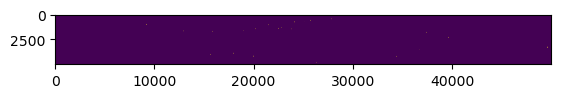

In [4]:
# labels, comment if unneeded.

# make_labels(LABEL_PATH, LABEL_OUT, height, width, transform, profile)

In [5]:
sources = {}
sources['DEM'] = ds.DataSource.from_tiff(
    DEM_PATH,
    type='DEM'
)

sources['LABELS'] = ds.DataSource.from_tiff(LABEL_OUT, type='LABELS'
    
)

In [6]:
stack = ds.DataStack(sources, TARGET_CRS, TARGET_RES, BOUNDS, labelled=True, features=['HILLSHADE', 'DEM'])

In [7]:
stack.tile_and_export(512, OUTPUT_PATH)

Exporting 1265 tiles 
  10 / 1265 tiles saved...
  20 / 1265 tiles saved...
  30 / 1265 tiles saved...
  40 / 1265 tiles saved...
  50 / 1265 tiles saved...
  60 / 1265 tiles saved...
  70 / 1265 tiles saved...
  80 / 1265 tiles saved...
  90 / 1265 tiles saved...
  100 / 1265 tiles saved...
  110 / 1265 tiles saved...
  120 / 1265 tiles saved...
  130 / 1265 tiles saved...
  140 / 1265 tiles saved...
  150 / 1265 tiles saved...
  160 / 1265 tiles saved...
  170 / 1265 tiles saved...
  180 / 1265 tiles saved...
  190 / 1265 tiles saved...
  200 / 1265 tiles saved...
  210 / 1265 tiles saved...
  220 / 1265 tiles saved...
  230 / 1265 tiles saved...
  240 / 1265 tiles saved...
  250 / 1265 tiles saved...
  260 / 1265 tiles saved...
  270 / 1265 tiles saved...
  280 / 1265 tiles saved...
  290 / 1265 tiles saved...
  300 / 1265 tiles saved...
  310 / 1265 tiles saved...
  320 / 1265 tiles saved...
  330 / 1265 tiles saved...
  340 / 1265 tiles saved...
  350 / 1265 tiles saved...
  360 /

In [8]:
import geopandas as gpd

gdf = gpd.read_file('../../../data/misc/DEMSHP.shp').to_crs('EPSG:27700')
minx, miny, maxx, maxy = gdf.total_bounds
bounds = (minx, miny, maxx, maxy)

In [9]:
bounds

(295472.4883689136, 99359.79931392297, 370304.66476089833, 156529.06448896838)